In [1]:
import tensorflow as tf
from tensorflow import keras
import os 
import zipfile
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

In [2]:
df = pd.read_csv('/Users/lokeshbudda/Desktop/NNDL/butterfly/Training_set.csv')

In [3]:
df.head()

,filename,label
0,Image_1.jpg,SOUTHERN DOGFACE
1,Image_2.jpg,ADONIS
2,Image_3.jpg,BROWN SIPROETA
3,Image_4.jpg,MONARCH
4,Image_5.jpg,GREEN CELLED CATTLEHEART


In [4]:
df['label'].unique()

array(['SOUTHERN DOGFACE', 'ADONIS', 'BROWN SIPROETA', 'MONARCH',
       'GREEN CELLED CATTLEHEART', 'CAIRNS BIRDWING',
       'EASTERN DAPPLE WHITE', 'RED POSTMAN', 'MANGROVE SKIPPER',
       'BLACK HAIRSTREAK', 'CABBAGE WHITE', 'RED ADMIRAL', 'PAINTED LADY',
       'PAPER KITE', 'SOOTYWING', 'PINE WHITE', 'PEACOCK',
       'CHECQUERED SKIPPER', 'JULIA', 'COMMON WOOD-NYMPH', 'BLUE MORPHO',
       'CLOUDED SULPHUR', 'STRAITED QUEEN', 'ORANGE OAKLEAF',
       'PURPLISH COPPER', 'ATALA', 'IPHICLUS SISTER', 'DANAID EGGFLY',
       'LARGE MARBLE', 'PIPEVINE SWALLOW', 'BLUE SPOTTED CROW',
       'RED CRACKER', 'QUESTION MARK', 'CRIMSON PATCH', 'BANDED PEACOCK',
       'SCARCE SWALLOW', 'COPPER TAIL', 'GREAT JAY', 'INDRA SWALLOW',
       'VICEROY', 'MALACHITE', 'APPOLLO', 'TWO BARRED FLASHER',
       'MOURNING CLOAK', 'TROPICAL LEAFWING', 'POPINJAY', 'ORANGE TIP',
       'GOLD BANDED', 'BECKERS WHITE', 'RED SPOTTED PURPLE',
       'MILBERTS TORTOISESHELL', 'SILVER SPOT SKIPPER', 'AMERICAN SN

In [5]:
df['label'].value_counts()

label
MOURNING CLOAK    131
SLEEPY ORANGE     107
ATALA             100
BROWN SIPROETA     99
CRECENT            97
                 ... 
AMERICAN SNOOT     74
GOLD BANDED        73
MALACHITE          73
CRIMSON PATCH      72
WOOD SATYR         71
Name: count, Length: 75, dtype: int64

In [6]:
df.shape

(6499, 2)

In [7]:
train_data, val_data = train_test_split(df, test_size=0.2, random_state=42)

In [8]:
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(
    rescale=1.0/255.0
)

In [9]:
image_size = (128,128)
batch_size = 32
epochs = 40

In [11]:
train_data = datagen.flow_from_dataframe(
    dataframe=train_data,
    directory='/Users/lokeshbudda/Desktop/NNDL/butterfly/test',  
    x_col='filename',            
    y_col='label',               
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
)

val_data = val_datagen.flow_from_dataframe(
    dataframe=val_data,
    directory='/Users/lokeshbudda/Desktop/NNDL/butterfly/train',  
    x_col='filename',            
    y_col='label',               
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
)

AttributeError: 'DataFrameIterator' object has no attribute 'copy'

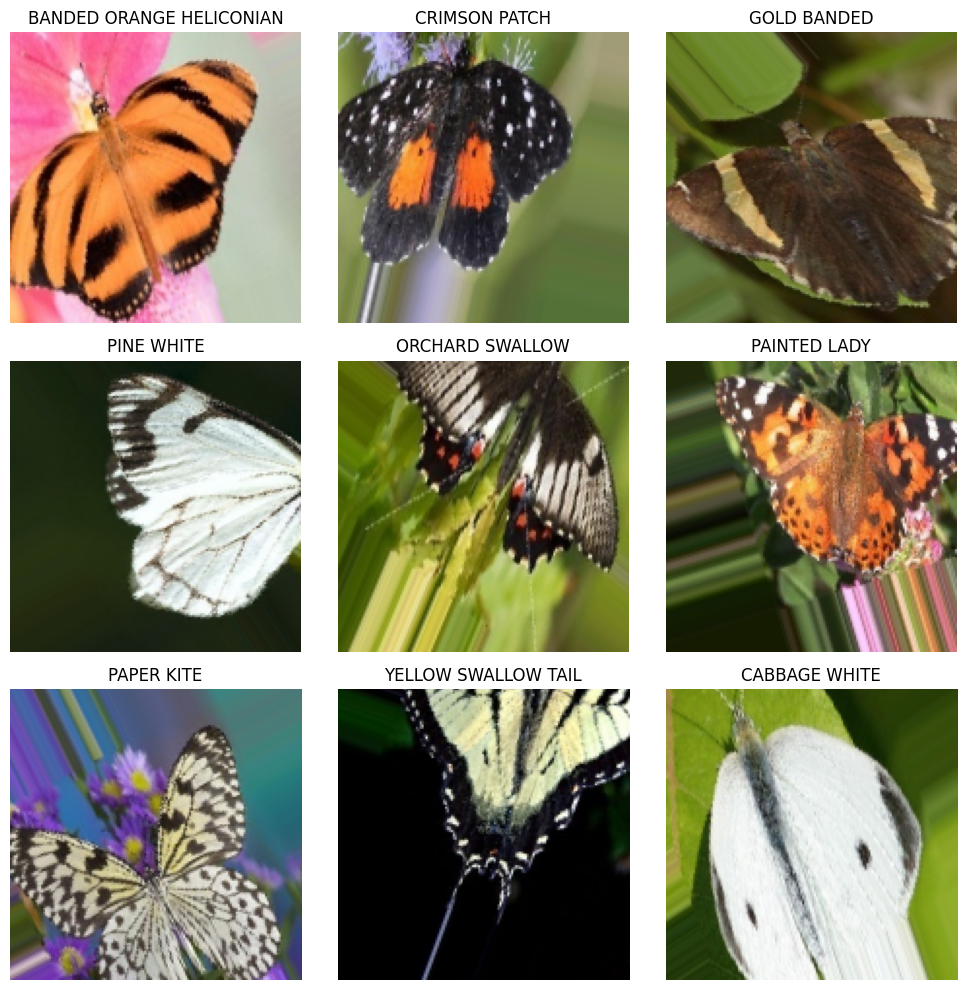

In [11]:
import matplotlib.pyplot as plt
import numpy as np

images, labels = next(train_data)

class_names = {v: k for k, v in train_data.class_indices.items()}

random_indices = np.random.choice(len(images), 9, replace=False)

plt.figure(figsize=(10, 10))
for i, idx in enumerate(random_indices):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[idx]) 
    label_index = np.argmax(labels[idx])  
    label_name = class_names[label_index]  
    plt.title(f"{label_name}")  
    plt.axis('off')  

plt.tight_layout()
plt.show()


# CNN Model

In [12]:
model = tf.keras.Sequential([

    tf.keras.layers.InputLayer(shape=(150,150,3)),
    
    tf.keras.layers.Conv2D(32, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    
    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(512, activation='relu'),  
    tf.keras.layers.Dense(df['label'].nunique(), activation='softmax')
])

In [13]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 148, 148, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 74, 74, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 72, 72, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 36, 36, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 34, 34, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 17, 17, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 36992)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │      18,940,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 75)                  │          38,475 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 19,072,139 (72.75 MB)

 Trainable params: 19,072,139 (72.75 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
model.compile(
      optimizer=tf.keras.optimizers.Adam(),
      loss='categorical_crossentropy',
      metrics=['accuracy']
  )


In [15]:
train_steps = int(train_data.n//batch_size)
val_steps = int(val_data.n//batch_size)

history = model.fit(train_data, 
          validation_data=val_data,
          epochs=epochs,
          steps_per_epoch=train_steps,
          validation_steps=val_steps)

Epoch 1/40


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


162/162 ━━━━━━━━━━━━━━━━━━━━ 66s 359ms/step - accuracy: 0.0220 - loss: 4.3491 - val_accuracy: 0.1078 - val_loss: 3.7388
Epoch 2/40
  1/162 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - accuracy: 0.0625 - loss: 3.5935

/usr/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


162/162 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.0625 - loss: 3.5935 - val_accuracy: 0.0000e+00 - val_loss: 4.2974
Epoch 3/40
162/162 ━━━━━━━━━━━━━━━━━━━━ 32s 190ms/step - accuracy: 0.1348 - loss: 3.4779 - val_accuracy: 0.2836 - val_loss: 2.6505
Epoch 4/40
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 125us/step - accuracy: 0.3125 - loss: 2.4846 - val_accuracy: 0.2500 - val_loss: 2.5243
Epoch 5/40
162/162 ━━━━━━━━━━━━━━━━━━━━ 32s 190ms/step - accuracy: 0.2620 - loss: 2.7658 - val_accuracy: 0.3586 - val_loss: 2.3761
Epoch 6/40
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 133us/step - accuracy: 0.2812 - loss: 2.7417 - val_accuracy: 0.4500 - val_loss: 2.1954
Epoch 7/40
162/162 ━━━━━━━━━━━━━━━━━━━━ 32s 188ms/step - accuracy: 0.3591 - loss: 2.3501 - val_accuracy: 0.4133 - val_loss: 2.0869
Epoch 8/40
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 127us/step - accuracy: 0.4375 - loss: 2.1274 - val_accuracy: 0.5500 - val_loss: 2.2348
Epoch 9/40
162/162 ━━━━━━━━━━━━━━━━━━━━ 32s 188ms/step - accuracy: 0.4193 - loss: 2.0823 - val_a

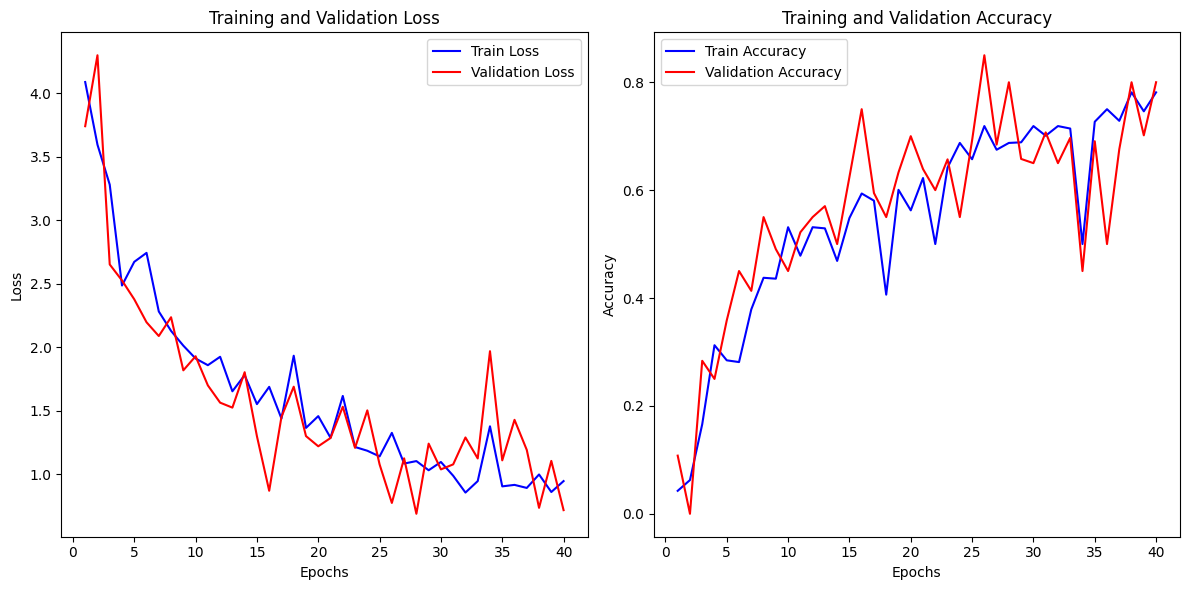

In [16]:
train_loss = history.history['loss']
val_loss = history.history['val_loss']
train_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']

epochs = range(1, len(train_loss) + 1)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(epochs, train_loss, label='Train Loss', color='blue')
plt.plot(epochs, val_loss, label='Validation Loss', color='red')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, train_accuracy, label='Train Accuracy', color='blue')
plt.plot(epochs, val_accuracy, label='Validation Accuracy', color='red')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()


plt.tight_layout()
plt.show()

## THANK YOU!!